In [2]:
#import required classes and packages
import torch
import pathlib
from ultralytics import YOLO
from pathlib import Path
import os
import cv2
import numpy as np
import pickle
import os
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from keras.callbacks import ModelCheckpoint
from keras.utils import to_categorical
from keras.models import Sequential, load_model, Model
from keras.applications import DenseNet121
from keras.layers import AveragePooling2D, Dropout, Flatten, Dense, Input
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt   
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn import metrics 
pathlib.PosixPath = pathlib.WindowsPath
%matplotlib inline

In [3]:
#yolo confidence threshold to detect skin disorder
CONFIDENCE_THRESHOLD = 0.50
GREEN = (0, 255, 0)
path = "Dataset"
labels = []
X = []
Y = []
for root, dirs, directory in os.walk(path):
    for j in range(len(directory)):
        name = os.path.basename(root)
        if name not in labels:
            labels.append(name.strip())   
print("Dataset Class Labels : "+str(labels))

Dataset Class Labels : ['Cheating', 'Nocheating']


In [4]:
#define function to get class label of given image
def getLabel(name):
    index = -1
    for i in range(len(labels)):
        if labels[i] == name:
            index = i
            break
    return index

In [5]:
#load dataset image and process them
if os.path.exists("model/X.txt.npy"):
    X = np.load('model/X.txt.npy')
    Y = np.load('model/Y.txt.npy')
else: #if images not process then read and process image pixels
    for root, dirs, directory in os.walk(path):#connect to dataset folder
        for j in range(len(directory)):#loop all images from dataset folder
            name = os.path.basename(root)
            if 'Thumbs.db' not in directory[j]:
                img = cv2.imread(root+"/"+directory[j])#read images
                img = cv2.resize(img, (80, 80))#resize image
                X.append(img) #add image pixels to X array
                label = getLabel(name)#get image label id
                Y.append(label)#add image label                
    X = np.asarray(X)#convert array as numpy array
    Y = np.asarray(Y)
    np.save('model/X.txt',X)#save process images and labels
    np.save('model/Y.txt',Y)
print("Dataset images loaded")
print("Total images found in dataset : "+str(X.shape[0]))
print()

Dataset images loaded
Total images found in dataset : 1071



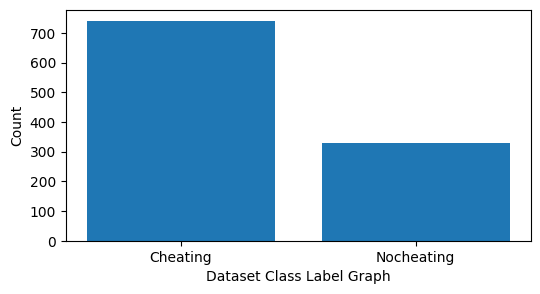

In [6]:
#visualizing class labels count found in dataset
names, count = np.unique(Y, return_counts = True)
height = count
bars = labels
y_pos = np.arange(len(bars))
plt.figure(figsize = (6, 3)) 
plt.bar(y_pos, height)
plt.xticks(y_pos, bars)
plt.xlabel("Dataset Class Label Graph")
plt.ylabel("Count")
plt.show()

In [7]:
#preprocess images like shuffling and normalization
X = X.astype('float32')
X = X/255 #normalized pixel values between 0 and 1
indices = np.arange(X.shape[0])
np.random.shuffle(indices)#shuffle all images
X = X[indices]
Y = Y[indices]
Y = to_categorical(Y)
#split dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)
print("Dataset Image Processing & Normalization Completed")
print("80% images used to train algorithms : "+str(X_train.shape[0]))
print("20% image used to train algorithms : "+str(X_test.shape[0]))

Dataset Image Processing & Normalization Completed
80% images used to train algorithms : 856
20% image used to train algorithms : 215


In [8]:
#define global variables to save accuracy and other metrics
accuracy = []
precision = []
recall = []
fscore = []

In [9]:
#function to calculate all metrics
def calculateMetrics(algorithm, testY, predict):
    p = precision_score(testY, predict,average='macro') * 100
    r = recall_score(testY, predict,average='macro') * 100
    f = f1_score(testY, predict,average='macro') * 100
    a = accuracy_score(testY,predict)*100
    accuracy.append(a)
    precision.append(p)
    recall.append(r)
    fscore.append(f)
    print(algorithm+" Accuracy  : "+str(a))
    print(algorithm+" Precision : "+str(p))
    print(algorithm+" Recall    : "+str(r))
    print(algorithm+" FSCORE    : "+str(f))
    conf_matrix = confusion_matrix(testY, predict)
    fig, axs = plt.subplots(1,2,figsize=(10, 3))
    ax = sns.heatmap(conf_matrix, xticklabels = labels, yticklabels = labels, annot = True, cmap="viridis" ,fmt ="g", ax=axs[0]);
    ax.set_ylim([0,len(labels)])
    axs[0].set_title(algorithm+" Confusion matrix") 

    random_probs = [0 for i in range(len(testY))]
    p_fpr, p_tpr, _ = roc_curve(testY, random_probs, pos_label=1)
    plt.plot(p_fpr, p_tpr, linestyle='--', color='orange',label="True classes")
    ns_fpr, ns_tpr, _ = roc_curve(testY, predict, pos_label=1)
    axs[1].plot(ns_fpr, ns_tpr, linestyle='--', label='Predicted Classes')
    axs[1].set_title(algorithm+" ROC AUC Curve")
    axs[1].set_xlabel('False Positive Rate')
    axs[1].set_ylabel('True Positive rate')
    plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step 
Existing DenseNet121 Accuracy  : 85.5813953488372
Existing DenseNet121 Precision : 80.52325581395348
Existing DenseNet121 Recall    : 77.36363636363637
Existing DenseNet121 FSCORE    : 78.73392680514341


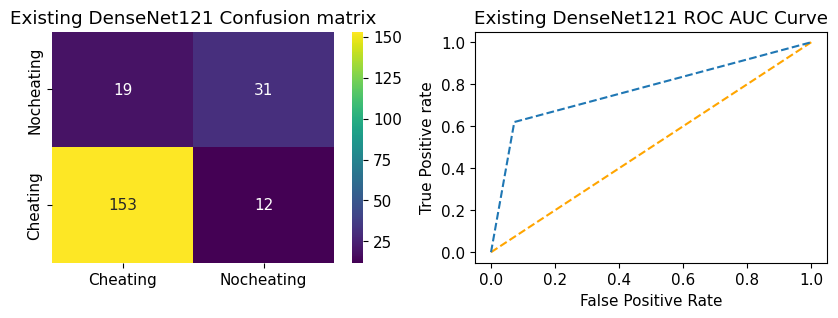

In [27]:
#training existing Densenet algorithm
densenet = DenseNet121(input_shape=(X_train.shape[1], X_train.shape[2], X_train.shape[3]), include_top=False, weights='imagenet')
for layer in densenet.layers:
    layer.trainable = False
headModel = densenet.output
headModel = AveragePooling2D(pool_size=(1, 1))(headModel)
headModel = Flatten(name="flatten")(headModel)
headModel = Dense(128, activation="relu")(headModel)
headModel = Dropout(0.3)(headModel)
headModel = Dense(y_train.shape[1], activation="softmax")(headModel)
densenet_model = Model(inputs=densenet.input, outputs=headModel)
densenet_model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
if os.path.exists("model/densenet_weights.hdf5") == False:
    model_check_point = ModelCheckpoint(filepath='model/densenet_weights.hdf5', verbose = 1, save_best_only = True)
    hist = densenet_model.fit(X_train, y_train, batch_size = 32, epochs = 15, validation_data=(X_test, y_test), callbacks=[model_check_point], verbose=1)
    f = open('model/densenet_history.pckl', 'wb')
    pickle.dump(hist.history, f)
    f.close()    
else:
    densenet_model.load_weights("model/densenet_weights.hdf5")
predict = densenet_model.predict(X_test)
predict = np.argmax(predict, axis=1)
y_test1 = np.argmax(y_test, axis=1)
calculateMetrics("Existing DenseNet121", y_test1, predict)

YOLOv5  v7.0-280-g4878541d Python-3.10.11 torch-2.3.1+cpu CPU

Fusing layers... 
Model summary: 157 layers, 7015519 parameters, 0 gradients, 15.8 GFLOPs
Adding AutoShape... 


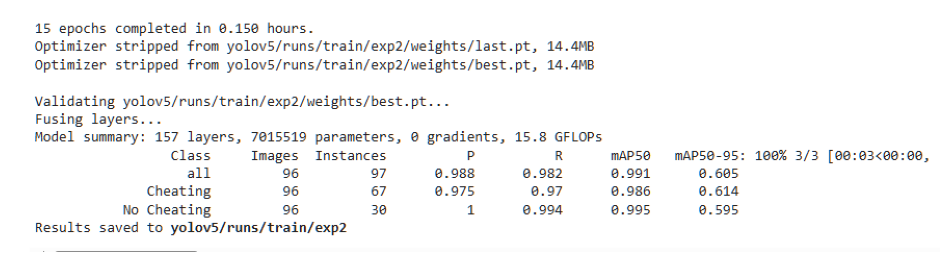

In [28]:
#train and load yolov5 model
yolov5_model = torch.hub.load('yolov5', 'custom', path='model/yolov5_best.pt', force_reload=True,source='local')
result = cv2.imread("model/yolov5_result.png")
plt.figure(figsize =(12, 6)) 
plt.imshow(result)
plt.axis('off')
plt.show()

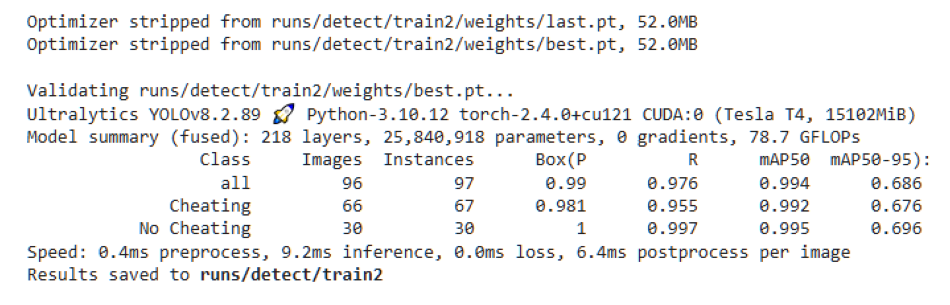

In [10]:
#loading yolo8 model extension
yolov8_extension = YOLO("model/yolov8_best.pt")
result = cv2.imread("model/yolov8_result.png")
plt.figure(figsize =(12, 6)) 
plt.imshow(result)
plt.axis('off')
plt.show()

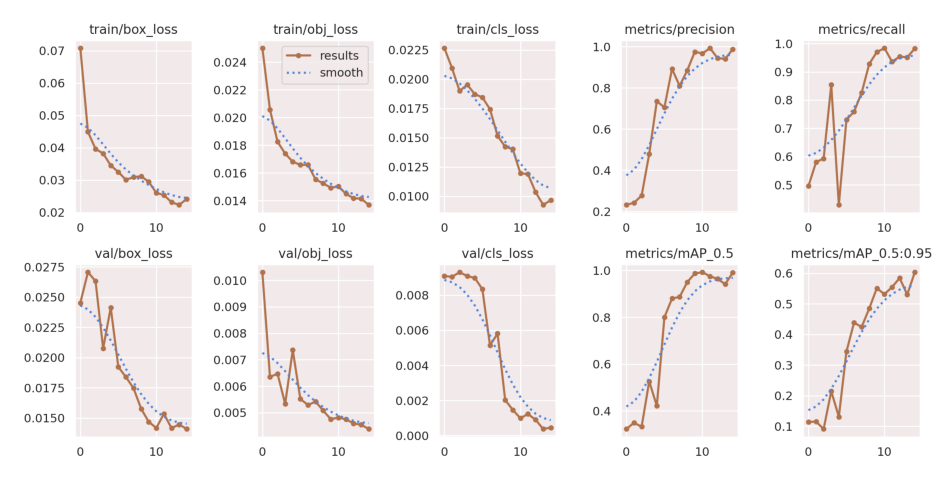

In [30]:
#yolov5 training graph
result = cv2.imread("model/yolov5_results.png")
plt.figure(figsize =(12, 6)) 
plt.imshow(result)
plt.axis('off')
plt.show()


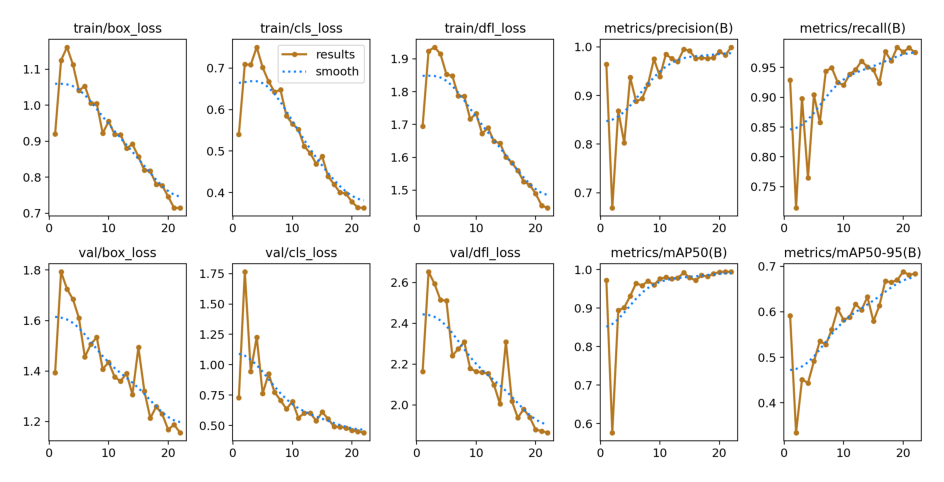

In [31]:
#yolov8 training graph
result = cv2.imread("model/yolov8_results.png")
plt.figure(figsize =(12, 6)) 
plt.imshow(result)
plt.axis('off')
plt.show()
